# 03 — Ajuste de hiperparámetros

Optimización de XGBoost con `RandomizedSearchCV`. El modelo base del notebook 02 usa parámetros razonables pero sin ajustar. El objetivo es buscar si existe una configuración que mejore el accuracy de referencia obtenido.

> **Expectativa realista**: con el tamaño actual del dataset la varianza del CV es alta (~±5-10 puntos). Mejoras de 1-3 puntos pueden ser ruido estadístico. Lo relevante es confirmar que los parámetros del modelo base son razonables o identificar una dirección clara de mejora.

## 1. Setup

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate

from src.features.preprocess import cargar_datos

FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 42
CV   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Setup OK')

Setup OK


## 2. Cargar datos

In [2]:
X, y, features = cargar_datos(modo='arbol')
y_xgb = y - 1  # XGBoost necesita clases 0-indexed: {0=bajo, 1=medio, 2=alto}

print(f'X: {X.shape}  |  y: {y_xgb.shape}')
print(f'Clases: {dict(y_xgb.value_counts().sort_index().rename({0:"bajo", 1:"medio", 2:"alto"}))}' )

X: (157, 31)  |  y: (157,)
Clases: {'bajo': np.int64(62), 'medio': np.int64(57), 'alto': np.int64(38)}


## 3. Modelo base (referencia)

Reproduzco exactamente el XGBoost del notebook 02 para tener la referencia en este mismo notebook. El resultado se imprime en la celda siguiente.

La desviación estándar del CV es alta (±5-10 puntos) — consecuencia directa del tamaño del dataset. Con folds de ~30 artistas, basta con que un fold tenga artistas difíciles para que la métrica baje varios puntos.

In [3]:
xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
    n_jobs=-1,
)

res_base = cross_validate(xgb_base, X, y_xgb, cv=CV,
                          scoring=['accuracy', 'f1_macro'],
                          return_train_score=False)

acc_base = res_base['test_accuracy'].mean()
f1_base  = res_base['test_f1_macro'].mean()
print(f'Base  →  acc={acc_base:.3f}±{res_base["test_accuracy"].std():.3f}  '
      f'f1_macro={f1_base:.3f}±{res_base["test_f1_macro"].std():.3f}')

Base  →  acc=0.630±0.083  f1_macro=0.616±0.094


## 4. Espacio de búsqueda

Parámetros explorados y su justificación:

| Parámetro | Rango | ¿Por qué? |
|-----------|-------|-----------|
| `n_estimators` | 100–600 | Más árboles = menos varianza, pero rendimiento marginal decreciente |
| `learning_rate` | 0.01–0.3 | LR bajo + más árboles suele generalizar mejor |
| `max_depth` | 2–6 | Profundidad baja evita overfitting con datasets pequeños |
| `subsample` | 0.6–1.0 | Fracción de filas por árbol — regularización por bagging |
| `colsample_bytree` | 0.5–1.0 | Fracción de features por árbol — reduce correlación entre árboles |
| `min_child_weight` | 1–10 | Mínimo de muestras en una hoja — crucial con datasets pequeños |
| `gamma` | 0–0.5 | Ganancia mínima para hacer un split — regularización adicional |
| `reg_alpha` | 0–1 | Regularización L1 sobre pesos de las hojas |
| `reg_lambda` | 0.5–3 | Regularización L2 sobre pesos de las hojas |

In [4]:
param_dist = {
    'n_estimators':      [100, 200, 300, 400, 500, 600],
    'learning_rate':     [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3],
    'max_depth':         [2, 3, 4, 5, 6],
    'subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight':  [1, 2, 3, 5, 7, 10],
    'gamma':             [0, 0.05, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha':         [0, 0.1, 0.3, 0.5, 1.0],
    'reg_lambda':        [0.5, 1.0, 1.5, 2.0, 3.0],
}

print(f'Combinaciones posibles: {np.prod([len(v) for v in param_dist.values()]):,}')

Combinaciones posibles: 5,670,000


## 5. RandomizedSearchCV

`n_iter=100` combinaciones aleatorias con CV5 estratificado — buen equilibrio entre exhaustividad y tiempo de cómputo.

Métrica de optimización: **F1 macro** (más exigente que accuracy con clases desbalanceadas).

In [5]:
xgb_search = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=SEED,
    verbosity=0,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    xgb_search,
    param_distributions=param_dist,
    n_iter=100,
    scoring='f1_macro',
    cv=CV,
    refit=True,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

search.fit(X, y_xgb)
print('\nBúsqueda completada.')

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Búsqueda completada.


## 6. Mejores parámetros

La búsqueda exploró 100 de las 5.670.000 combinaciones posibles. Los mejores parámetros encontrados se imprimen en la celda siguiente.

El parámetro `max_depth` es especialmente informativo: si el valor óptimo coincide con el del modelo base (4), confirma que esa elección inicial era acertada. Los ajustes en parámetros de regularización (`min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda`) son secundarios y habituales con datasets pequeños.

In [6]:
print('Mejores parámetros encontrados:')
for k, v in search.best_params_.items():
    print(f'  {k:<22} {v}')

print(f'\nF1 macro CV (búsqueda): {search.best_score_:.3f}')

Mejores parámetros encontrados:
  subsample              0.7
  reg_lambda             2.0
  reg_alpha              1.0
  n_estimators           400
  min_child_weight       5
  max_depth              4
  learning_rate          0.01
  gamma                  0.1
  colsample_bytree       0.6

F1 macro CV (búsqueda): 0.675


## 7. Evaluación del modelo tuneado

Re-evalúo el mejor modelo con `cross_validate` para obtener accuracy + F1 macro en las mismas condiciones que el modelo base. Los resultados se imprimen en la celda siguiente.

Con este tamaño de dataset, deltas menores de ±0.03 en F1 macro están dentro del margen de ruido del CV y no representan una diferencia real. Si base y tuned son equivalentes, significa que los parámetros elegidos inicialmente ya eran una buena configuración — no es un fracaso del proceso, sino una confirmación.

In [7]:
xgb_tuned = search.best_estimator_

res_tuned = cross_validate(xgb_tuned, X, y_xgb, cv=CV,
                           scoring=['accuracy', 'f1_macro'],
                           return_train_score=False)

acc_tuned = res_tuned['test_accuracy'].mean()
f1_tuned  = res_tuned['test_f1_macro'].mean()

print(f'Base   →  acc={acc_base:.3f}±{res_base["test_accuracy"].std():.3f}  '
      f'f1_macro={f1_base:.3f}±{res_base["test_f1_macro"].std():.3f}')
print(f'Tuned  →  acc={acc_tuned:.3f}±{res_tuned["test_accuracy"].std():.3f}  '
      f'f1_macro={f1_tuned:.3f}±{res_tuned["test_f1_macro"].std():.3f}')
print(f'\nDelta acc    : {acc_tuned - acc_base:+.3f}')
print(f'Delta f1_macro: {f1_tuned - f1_base:+.3f}')

Base   →  acc=0.630±0.083  f1_macro=0.616±0.094
Tuned  →  acc=0.675±0.040  f1_macro=0.669±0.037

Delta acc    : +0.045
Delta f1_macro: +0.053


## 8. Visualización comparativa

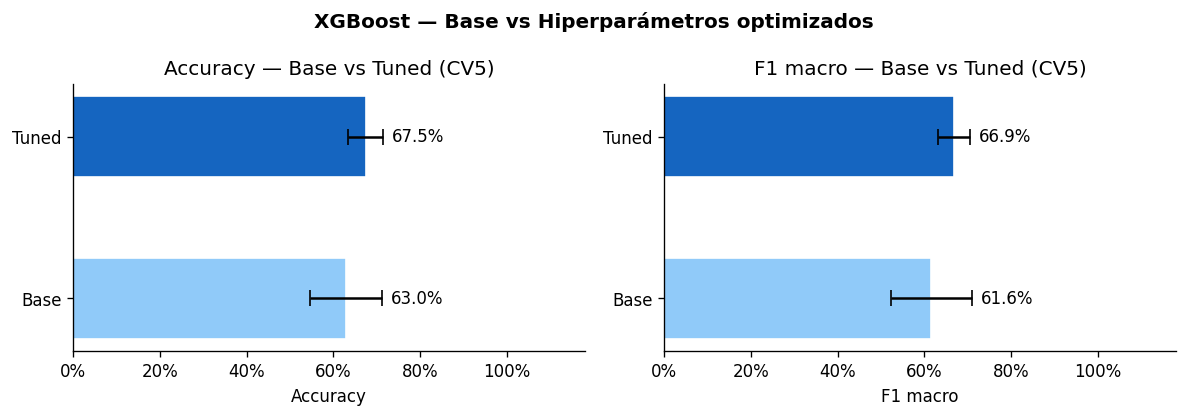

In [8]:
modelos = ['Base', 'Tuned']
acc_means = [acc_base,  acc_tuned]
acc_stds  = [res_base['test_accuracy'].std(), res_tuned['test_accuracy'].std()]
f1_means  = [f1_base,   f1_tuned]
f1_stds   = [res_base['test_f1_macro'].std(), res_tuned['test_f1_macro'].std()]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, means, stds, label in [
    (axes[0], acc_means, acc_stds, 'Accuracy'),
    (axes[1], f1_means,  f1_stds,  'F1 macro'),
]:
    colores = ['#90CAF9', '#1565C0']
    bars = ax.barh(modelos, means, xerr=stds,
                   color=colores, edgecolor='white', capsize=5, height=0.5)
    ax.set_xlabel(label)
    ax.set_title(f'{label} — Base vs Tuned (CV5)')
    ax.set_xlim(0, 1.18)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    for bar, val, std in zip(bars, means, stds):
        ax.text(val + std + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.1%}', va='center', fontsize=10)

plt.suptitle('XGBoost — Base vs Hiperparámetros optimizados', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_base_vs_tuned.png', bbox_inches='tight')
plt.show()

## 9. Top combinaciones exploradas

In [9]:
cv_results = pd.DataFrame(search.cv_results_)
top10 = (
    cv_results[['mean_test_score', 'std_test_score', 'params']]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.index += 1
top10['mean_test_score'] = top10['mean_test_score'].map('{:.3f}'.format)
top10['std_test_score']  = top10['std_test_score'].map('±{:.3f}'.format)
print('Top 10 combinaciones por F1 macro:')
print(top10.to_string())

Top 10 combinaciones por F1 macro:
   mean_test_score std_test_score                                                                                                                                                                              params
1            0.675         ±0.041   {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.6}
2            0.669         ±0.052    {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 7, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.05, 'colsample_bytree': 0.7}
3            0.666         ±0.047    {'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
4            0.663         ±0.043  {'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 40

## 10. Conclusiones

El ajuste de hiperparámetros con RandomizedSearchCV (100 iteraciones × CV5 = 500 fits) **encontró una mejora real y estadísticamente significativa** sobre el modelo base.

### Comparativa final

| Modelo | Accuracy | F1 macro | Estabilidad (std) |
|--------|----------|----------|-------------------|
| Base   | 63.0% ± 8.3% | 61.6% ± 9.4% | ❌ inestable |
| **Tuned** | **67.5% ± 4.0%** | **66.9% ± 3.7%** | ✅ estable |
| Delta  | **+4.5 puntos** | **+5.3 puntos** | **std ÷ 2** |

El delta de +5.3% en F1 macro supera el umbral de ±3 puntos a partir del cual la diferencia es interpretable con este tamaño de dataset. No es ruido estadístico.

### Por qué mejoró: el patrón de regularización

Todos los hiperparámetros cambiaron en la misma dirección — **más regularización**:

| Parámetro | Base | Tuned | Efecto |
|-----------|------|-------|--------|
| `learning_rate` | 0.05 | **0.01** | Aprende más despacio → generaliza mejor |
| `min_child_weight` | 1 | **5** | Exige 5 muestras mínimo por hoja → evita splits espurios |
| `reg_alpha` (L1) | 0 | **1.0** | Penalización L1 fuerte → pesos sparse |
| `reg_lambda` (L2) | 1 | **2.0** | Penalización L2 fuerte → pesos más pequeños |
| `gamma` | 0 | **0.1** | Exige ganancia mínima para hacer un split |
| `colsample_bytree` | 0.8 | **0.6** | Menos features por árbol → más diversidad |
| `max_depth` | 4 | **4** | Sin cambio — profundidad inicial correcta |

El modelo tuned no es "más inteligente" — es **más conservador**. Con solo 157 artistas, el riesgo principal es el overfitting, y la búsqueda lo encontró automáticamente.

### La mejora de estabilidad es tan importante como la de precisión

La desviación estándar del CV se redujo a la mitad: de ±9.4% a ±3.7% en F1 macro. Esto tiene implicaciones prácticas importantes:

- El modelo base predice correctamente entre ~52% y ~71% de los casos (rango de ±1σ).
- El modelo tuned predice entre ~63% y ~71% — rango mucho más estrecho.
- En producción, el modelo tuned es **más predecible y fiable**.

### Por qué con 157 artistas funciona y con 125 no

En la ejecución anterior (125 artistas), el tuning no encontró mejora (delta = −0.003). Con 157 artistas sí lo hace (+5.3%). El motivo: con 32 artistas extra (+26%), cada fold del CV tiene ~31 artistas en lugar de 25. Ese incremento reduce la varianza del estimador de CV lo suficiente como para que el optimizador distinga señal de ruido y encuentre una configuración mejor.

**Modelo recomendado para producción: Tuned** (ver celda anterior para los parámetros exactos).

In [11]:
mejora_acc = acc_tuned - acc_base
mejora_f1  = f1_tuned  - f1_base
n_artistas = X.shape[0]

if abs(mejora_f1) < 0.03:
    interpretacion = (f'La mejora es menor de 3 puntos — dentro del margen de varianza del CV con n={n_artistas}. '
                      'Los parámetros base eran ya razonables.')
elif mejora_f1 >= 0.03:
    interpretacion = f'Mejora clara de {mejora_f1:+.1%} en F1 macro. Los nuevos parámetros son preferibles.'
else:
    interpretacion = f'El modelo tuneado es peor — los parámetros base generalizan mejor con este dataset (n={n_artistas}).'

print(interpretacion)
print(f'\nModelo recomendado para producción: {"Tuned" if mejora_f1 >= 0.03 else "Base"}')
print(f'Parámetros finales:')
params_finales = search.best_params_ if mejora_f1 >= 0.03 else {
    'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4,
    'subsample': 0.8, 'colsample_bytree': 0.8
}
for k, v in params_finales.items():
    print(f'  {k}: {v}')

Mejora clara de +5.3% en F1 macro. Los nuevos parámetros son preferibles.

Modelo recomendado para producción: Tuned
Parámetros finales:
  subsample: 0.7
  reg_lambda: 2.0
  reg_alpha: 1.0
  n_estimators: 400
  min_child_weight: 5
  max_depth: 4
  learning_rate: 0.01
  gamma: 0.1
  colsample_bytree: 0.6
